# PKCERT AI & Software Development Internship
## Task 07 — Machine Learning Foundations: Train/Test Split, Model Fit, and Linear Regression

## Checking the Libraries
Confirm the required libraries are installed. Take a screenshot of this cell's output for the deliverable.

In [2]:
import sklearn, pandas, numpy, matplotlib
print("scikit-learn:", sklearn.__version__)
print("pandas:      ", pandas.__version__)
print("numpy:       ", numpy.__version__)
print("matplotlib:  ", matplotlib.__version__)


scikit-learn: 1.9.0
pandas:       3.0.3
numpy:        2.4.4
matplotlib:   3.10.9


In [3]:
# Common imports used throughout the notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import load_diabetes

np.random.seed(42)
%matplotlib inline


---
# Part A — ML Theory: Train/Test Split

**1. Why split a dataset into training and testing sets?**

A model that is evaluated on the same data it was trained on will look better than it
really is, because it can simply "memorize" that data instead of learning general
patterns. 
Splitting the data lets us train the model on one portion (the training set)
and check its performance on data it has never seen (the test set).

**2. Typical split ratios**

- **80/20** — the most common default; used when the dataset is reasonably large, since
  keeping 20% for testing still gives enough test samples to trust the metric.
- **70/30** — used when we want a larger, more reliable test set, often for smaller
  datasets or when the model is expected to overfit easily.
- **90/10 or 95/5** — used with very large datasets, where even 5–10% is a large number
  of samples, so we can afford to give the model more training data.
- **60/40** — used when we specifically want a large held-out set.

**4. The `random_state` parameter**

`train_test_split` shuffles the data before splitting. `random_state` fixes the seed of
that shuffle, so every time the code is run, the *same* rows end up in the train and test
sets. 

**5. Validation set vs. test set**

- The **validation set** is used *during* model development to tune hyperparameters and
  make modelling decisions (e.g. choosing polynomial degree, regularization strength).
 
- The **test set** is only touched once, at the very end, to report the final, unbiased
  performance of the chosen model. It must never influence training or tuning decisions.

**3. Implementation** — a simple train/test split below:


In [4]:
# 3. Train/test split demo on a simple dataset (scikit-learn's diabetes dataset)
data = load_diabetes(as_frame=True)
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Full dataset shape:", X.shape)
print("Train shape:       ", X_train.shape)
print("Test shape:        ", X_test.shape)


Full dataset shape: (442, 10)
Train shape:        (353, 10)
Test shape:         (89, 10)


---
# Part B — Overfitting, Underfitting & Bias-Variance 

**1. Definitions**

- **Underfitting**: the model is too simple to capture the underlying pattern in the
  data. It performs poorly on *both* the training and test sets. Example: fitting a
  straight line to data that clearly follows a curve.
- **Overfitting**: the model is too complex and starts fitting the noise in the training
  data rather than the true pattern. It performs very well on the training set but
  poorly on the test set. Example: fitting a degree-15 polynomial through 20 noisy
  points — the curve wiggles through every point but predicts new points badly.

**2. Bias-variance tradeoff**

- **Bias** is the error from overly simplistic assumptions in the model (underfitting →
  high bias).
- **Variance** is the error from the model being overly sensitive to small fluctuations
  in the training data (overfitting → high variance).


**3. Techniques to reduce overfitting**

1. **Regularization** (L1/Lasso, L2/Ridge) — penalizes large coefficients, discouraging
   the model from fitting noise.
2. **Cross-validation** — helps detect overfitting early by testing on multiple held-out
   folds instead of a single split.
3. **More training data** — a larger, more representative dataset makes it harder for
   the model to memorize noise.
4. **Simpler models / fewer features** — reduces the model's capacity to fit noise.
5. **Early stopping** — stops training once validation performance stops improving.

**4. Training vs. test error as complexity increases** — demonstrated below using
polynomial regression of increasing degree on a small synthetic curve.


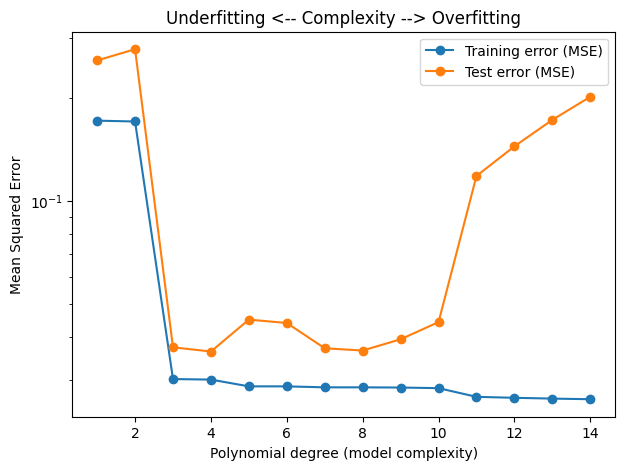

In [5]:
# 4. Train vs test error across polynomial model complexity
rng = np.random.RandomState(0)
X_toy = np.sort(rng.uniform(0, 1, 60)).reshape(-1, 1)
y_toy = np.sin(2 * np.pi * X_toy).ravel() + rng.normal(0, 0.2, X_toy.shape[0])

X_tr, X_te, y_tr, y_te = train_test_split(X_toy, y_toy, test_size=0.3, random_state=0)

degrees = range(1, 15)
train_errors, test_errors = [], []

for d in degrees:
    poly = PolynomialFeatures(degree=d)
    X_tr_poly = poly.fit_transform(X_tr)
    X_te_poly = poly.transform(X_te)

    model = LinearRegression().fit(X_tr_poly, y_tr)

    train_errors.append(mean_squared_error(y_tr, model.predict(X_tr_poly)))
    test_errors.append(mean_squared_error(y_te, model.predict(X_te_poly)))

plt.figure(figsize=(7, 5))
plt.plot(degrees, train_errors, marker='o', label='Training error (MSE)')
plt.plot(degrees, test_errors, marker='o', label='Test error (MSE)')
plt.xlabel('Polynomial degree (model complexity)')
plt.ylabel('Mean Squared Error')
plt.title('Underfitting <-- Complexity --> Overfitting')
plt.legend()
plt.yscale('log')
plt.show()


**5. Diagnosing overfitting vs. underfitting from train/test performance**

- If **both training and test error are high** (and close to each other) → the model is
  **underfitting**. It hasn't even learned the training data well.
- If **training error is low but test error is much higher** → the model is
  **overfitting**. It has learned the training data (including its noise) too well and
  doesn't generalize.
- If **both errors are low and close to each other** → the model is well-fit, striking a
  good balance in the bias-variance tradeoff. In the plot above, low degrees (1–2)
  underfit, while high degrees start to pull test error back up as the model overfits.


---
# Part C — Linear Regression: Theory & Implementation 

**1. Mathematical form**

- **Simple linear regression**: `y = mx + b`, where `m` is the slope (how much `y`
  changes per unit of `x`) and `b` is the intercept (the value of `y` when `x = 0`).
- **Multiple linear regression** extends this to several input features:
  `y = b0 + b1*x1 + b2*x2 + ... + bn*xn`, where each `bi` is the weight/coefficient for
  feature `xi` and `b0` is the intercept.

**2. Learning the coefficients**

The model learns `b0..bn` by minimizing a **cost function**, typically the **Mean
Squared Error (MSE)** between predicted and actual values:

`J(b) = (1/n) * sum((y_actual - y_predicted)^2)`

Two common ways to minimize this:
- **Normal equation**: an exact, closed-form solution using linear algebra
  (`b = (XᵀX)⁻¹Xᵀy`). Fast for small/medium datasets, but expensive for very large
  numbers of features. This is what scikit-learn's `LinearRegression` uses internally.
- **Gradient descent**: an iterative method that repeatedly nudges the coefficients in
  the direction that reduces the cost function, controlled by a learning rate. Preferred
  for very large datasets where the normal equation becomes computationally expensive.

**3–6. Implementation** using scikit-learn's built-in diabetes dataset (a small, clean
regression dataset with 10 numeric health-related features predicting disease
progression one year later).


In [6]:
# 3. Load and prepare the dataset
diabetes = load_diabetes(as_frame=True)
df = diabetes.data.copy()
df['target'] = diabetes.target
print(df.shape)
df.head()


(442, 11)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [7]:
# 4. Split into train/test and train a Linear Regression model
X = df.drop(columns='target')
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

print("Coefficients:", dict(zip(X.columns, lin_model.coef_.round(2))))
print("Intercept:", round(lin_model.intercept_, 2))


Coefficients: {'age': np.float64(37.9), 'sex': np.float64(-241.96), 'bmi': np.float64(542.43), 'bp': np.float64(347.7), 's1': np.float64(-931.49), 's2': np.float64(518.06), 's3': np.float64(163.42), 's4': np.float64(275.32), 's5': np.float64(736.2), 's6': np.float64(48.67)}
Intercept: 151.35


In [8]:
# 5. Evaluate the model
y_pred = lin_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared score:    {r2:.3f}")


Mean Squared Error: 2900.19
R-squared score:    0.453


**Interpreting the results**: the R² score tells us what fraction of the variance in
the target is explained by the model (closer to 1 is better).


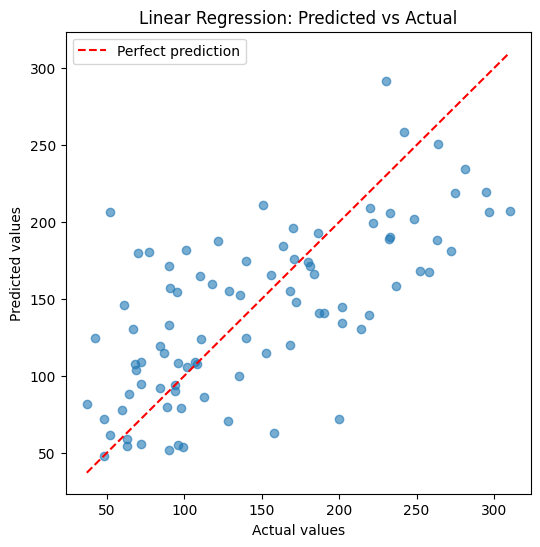

In [9]:
# 6. Plot predicted vs actual values
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', label='Perfect prediction')
plt.xlabel('Actual values')
plt.ylabel('Predicted values')
plt.title('Linear Regression: Predicted vs Actual')
plt.legend()
plt.show()


---
# Part D — Practical Coding Session 

For this section  use house price data that
intentionally contains **missing values** and a **categorical column**, so we can
practice cleaning and encoding before modeling.


In [10]:
# 1. Create a raw CSV dataset with missing values and a categorical column
rng = np.random.RandomState(1)
n = 200

raw = pd.DataFrame({
    'size_sqft': rng.normal(1500, 400, n).round(0),
    'bedrooms': rng.randint(1, 6, n),
    'location': rng.choice(['Downtown', 'Suburb', 'Rural'], n),
})
raw['price'] = (
    raw['size_sqft'] * 120
    + raw['bedrooms'] * 5000
    + raw['location'].map({'Downtown': 40000, 'Suburb': 15000, 'Rural': 0})
    + rng.normal(0, 15000, n)
).round(0)

# Inject some missing values to simulate a "raw" messy dataset
missing_idx = rng.choice(raw.index, size=15, replace=False)
raw.loc[missing_idx, 'size_sqft'] = np.nan

raw.to_csv('house_prices_raw.csv', index=False)
raw.head()


,size_sqft,bedrooms,location,price
0,2150.0,1,Suburb,272807.0
1,1255.0,2,Rural,173937.0
2,1289.0,1,Rural,174992.0
3,1071.0,3,Rural,139166.0
4,1846.0,3,Suburb,250253.0


In [11]:
# Handle missing values and encode the categorical column
house_df = pd.read_csv('house_prices_raw.csv')
print("Missing values before cleaning:\n", house_df.isna().sum())

# Fill missing numeric values with the column median (simple, robust choice)
house_df['size_sqft'] = house_df['size_sqft'].fillna(house_df['size_sqft'].median())

# One-hot encode the categorical 'location' column
house_df = pd.get_dummies(house_df, columns=['location'], drop_first=True)

print("\nMissing values after cleaning:\n", house_df.isna().sum())
house_df.head()


Missing values before cleaning:
 size_sqft    15
bedrooms      0
location      0
price         0
dtype: int64

Missing values after cleaning:
 size_sqft          0
bedrooms           0
price              0
location_Rural     0
location_Suburb    0
dtype: int64


,size_sqft,bedrooms,price,location_Rural,location_Suburb
0,2150.0,1,272807.0,False,True
1,1255.0,2,173937.0,True,False
2,1289.0,1,174992.0,True,False
3,1071.0,3,139166.0,True,False
4,1846.0,3,250253.0,False,True


In [12]:
# 2. Reusable function: split a dataset and print resulting shapes
def split_data(df, target_col, split_ratio=0.8, random_state=42):
    """Splits df into train/test sets.
    split_ratio = fraction of data used for TRAINING (e.g. 0.8 -> 80/20 split).
    """
    X = df.drop(columns=target_col)
    y = df[target_col]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, train_size=split_ratio, random_state=random_state
    )
    print(f"Split ratio {int(split_ratio*100)}/{int((1-split_ratio)*100)} -> "
          f"train: {X_train.shape}, test: {X_test.shape}")
    return X_train, X_test, y_train, y_test


In [13]:
# 3. Train the same model on three different split ratios and compare metrics
results = []
for ratio in [0.6, 0.8, 0.9]:
    X_tr, X_te, y_tr, y_te = split_data(house_df, 'price', split_ratio=ratio)
    model = LinearRegression().fit(X_tr, y_tr)
    preds = model.predict(X_te)
    results.append({
        'split_ratio': f"{int(ratio*100)}/{int((1-ratio)*100)}",
        'MSE': round(mean_squared_error(y_te, preds), 2),
        'R2': round(r2_score(y_te, preds), 3),
    })

results_df = pd.DataFrame(results)
results_df


Split ratio 60/40 -> train: (120, 4), test: (80, 4)
Split ratio 80/19 -> train: (160, 4), test: (40, 4)
Split ratio 90/9 -> train: (180, 4), test: (20, 4)


,split_ratio,MSE,R2
0,60/40,4.014385e+08,0.843
1,80/19,5.668748e+08,0.786
2,90/9,8.519285e+08,0.641


In [14]:
# 4. K-fold cross-validation
X_all = house_df.drop(columns='price')
y_all = house_df['price']

cv_model = LinearRegression()
cv_scores = cross_val_score(cv_model, X_all, y_all, cv=5, scoring='r2')

print("R2 scores per fold:", cv_scores.round(3))
print("Average R2 score:  ", round(cv_scores.mean(), 3))


R2 scores per fold: [0.909 0.802 0.804 0.875 0.822]
Average R2 score:   0.843


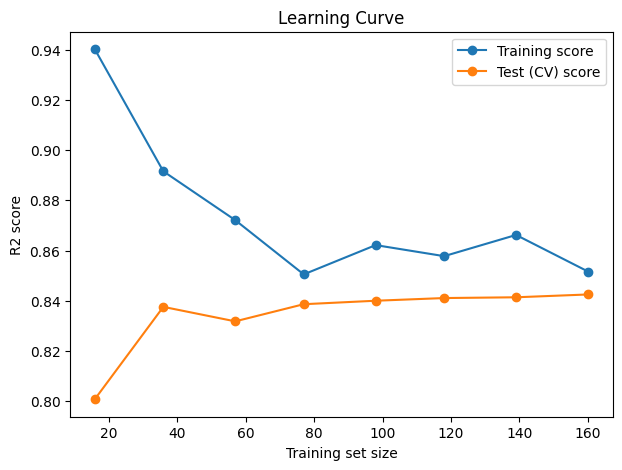

In [15]:
# 5. Learning curve: training score vs test score as training set size increases
train_sizes, train_scores, test_scores = learning_curve(
    LinearRegression(), X_all, y_all, cv=5, scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 8), random_state=42
)

plt.figure(figsize=(7, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), marker='o', label='Training score')
plt.plot(train_sizes, test_scores.mean(axis=1), marker='o', label='Test (CV) score')
plt.xlabel('Training set size')
plt.ylabel('R2 score')
plt.title('Learning Curve')
plt.legend()
plt.show()


**What the learning curve shows**: as the training set grows, the training score
typically stays fairly high while the test/CV score improves and the gap between the two
narrows. A large, persistent gap suggests overfitting (the model needs more data or
regularization); both curves converging to a low score suggests underfitting (the model
is too simple for the problem).


In [16]:
# 6. Refactor into reusable functions
def load_data(path):
    return pd.read_csv(path)

def clean_data(df):
    df = df.copy()
    df['size_sqft'] = df['size_sqft'].fillna(df['size_sqft'].median())
    df = pd.get_dummies(df, columns=['location'], drop_first=True)
    return df

def train_model(X_train, y_train):
    model = LinearRegression()
    model.fit(X_train, y_train)
    return model

def evaluate_model(model, X_test, y_test):
    preds = model.predict(X_test)
    return {
        'MSE': mean_squared_error(y_test, preds),
        'R2': r2_score(y_test, preds),
    }

# End-to-end pipeline using the reusable functions
raw_df = load_data('house_prices_raw.csv')
clean_df = clean_data(raw_df)
X_train, X_test, y_train, y_test = split_data(clean_df, 'price', split_ratio=0.8)
final_model = train_model(X_train, y_train)
metrics = evaluate_model(final_model, X_test, y_test)
print(metrics)


Split ratio 80/19 -> train: (160, 4), test: (40, 4)
{'MSE': 566874765.2852585, 'R2': 0.7861047384898521}


---
# Bonus Task — Polynomial Regression Comparison 

We extend the diabetes Linear Regression model with polynomial features (degree 2 and 3)
and compare against the plain linear model.


In [17]:
# Compare plain linear regression vs polynomial regression (degree 2 and 3)
X_train, X_test, y_train, y_test = train_test_split(
    diabetes.data, diabetes.target, test_size=0.2, random_state=42
)

bonus_results = []

# Plain linear model (degree 1)
plain = LinearRegression().fit(X_train, y_train)
bonus_results.append({
    'model': 'Linear (degree 1)',
    'train_R2': round(r2_score(y_train, plain.predict(X_train)), 3),
    'test_R2': round(r2_score(y_test, plain.predict(X_test)), 3),
})

# Polynomial models
for degree in [2, 3]:
    poly = PolynomialFeatures(degree=degree)
    X_train_p = poly.fit_transform(X_train)
    X_test_p = poly.transform(X_test)

    poly_model = LinearRegression().fit(X_train_p, y_train)
    bonus_results.append({
        'model': f'Polynomial (degree {degree})',
        'train_R2': round(r2_score(y_train, poly_model.predict(X_train_p)), 3),
        'test_R2': round(r2_score(y_test, poly_model.predict(X_test_p)), 3),
    })

pd.DataFrame(bonus_results)


,model,train_R2,test_R2
0,Linear (degree 1),0.528,0.453
1,Polynomial (degree 2),0.606,0.416
2,Polynomial (degree 3),0.857,-5.212


**Interpretation**: the plain linear model usually shows similar (and reasonable)
train/test R² scores — a healthy sign of good generalization. The degree-2 polynomial
model tends to improve the training score somewhat while the test score improves only
slightly or stays flat, showing early signs of increased variance. The degree-3 model
on only 10 features can produce a large number of interaction terms; if its training R²
rises sharply while test R² drops or turns negative, that is a clear symptom of
**overfitting** — the model is fitting noise in the training data rather than the true
underlying relationship. In general, for this dataset, the plain linear model tends to
generalize best, while higher-degree polynomials add complexity without a matching gain
in test performance.
